In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from collections import Counter
import string
import time
import copy
import random

import preprocess
import model_arch

In [2]:
def get_device():
    if torch.backends.mps.is_available():
        print("MPS is available")
        return torch.device("mps")
    elif torch.cuda.is_available():
        print("CUDA is available")
        return torch.device("cuda")
    else:
        print("CPU is available")
        return torch.device("cpu")

In [3]:
EMBEDDING_SIZE = 256
WINDOW_SIZE = 2
BATCH_SIZE = 128

DATA_PATH = "data/comb.txt"
NEW_DATA_PATH = "data/war_and_peace.txt"
MODEL_FILE = "cbow_model_cpu_3.pt"

DEVICE = get_device() # torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print('Using device:', str(DEVICE).upper(), "\n")

MPS is available
Using device: MPS 



In [4]:
sequence, vocab_size = preprocess.get_sequence(DATA_PATH)
dataset = model_arch.CBOWDataset(sequence, WINDOW_SIZE)

model = model_arch.CBOWModel(vocab_size, EMBEDDING_SIZE)
model.load_state_dict(torch.load(f"model/{MODEL_FILE}"))

print(f" -- Model nn.Embedding shape: {model.embedding.weight.data.shape}")
print(f" -- Model nn.Linear shape: {model.fc.weight.data.shape}")

 -- Total number of tokens: 1959021
 -- Vocab size is: 72502
 -- Model nn.Embedding shape: torch.Size([72502, 256])
 -- Model nn.Linear shape: torch.Size([72502, 256])


In [ ]:
##################################################################################
# Model resizing

In [5]:
vocab, _ = preprocess.get_index(DATA_PATH)
print(" --- Initial vocab size:", len(vocab))

new_vocab = copy.deepcopy(vocab)
last_value = len(new_vocab)
for k, v in preprocess.get_index(NEW_DATA_PATH)[0].items():
    if new_vocab.get(k, None) == None:
        new_vocab[k] = last_value
        last_value += 1

new_vocab_size = len(new_vocab)
print(" --- New vocab size:", new_vocab_size)

if len(new_vocab) > len(vocab):
    model.embedding = preprocess.resize_embedding(model.embedding, len(new_vocab))

    # # This resizing affects only to linear part of weights and do not use.
    # # Do we need to use it???
    # model.fc = preprocess.resize_linear(model.fc, len(new_vocab))

 --- Initial vocab size: 72502
 --- New vocab size: 72816
 -- Old embeddings size: torch.Size([72502, 256])
 -- New embeddings size:torch.Size([72816, 256])


In [ ]:
# model = CBOWModel(vocab_size, EMBEDDING_SIZE)
# model = model.to(DEVICE)

In [114]:
# # Uncomment it to load the pretrained model
# model = CBOWModel(vocab_size, EMBEDDING_SIZE)
# model.load_state_dict(torch.load(f"model/{MODEL_FILE}"))
# model = model.to(DEVICE)

In [8]:
model = model.to(DEVICE)

epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

for epoch in range(epochs):
    start = time.perf_counter()
    
    total_loss = 0
    for context, target in dataloader:
        context, target = context.to(DEVICE), target.to(DEVICE) # move to GPU
        
        optimizer.zero_grad()
        logits = model(context)
        loss = criterion(logits, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    end = time.perf_counter()

    print(f" ---- Epoch {epoch+1}, Loss: {total_loss:.4f}, Execution time: {end - start:.6f}")

 ---- Epoch 1, Loss: 49096.5843, Execution time: 440.857235


KeyboardInterrupt: 

In [9]:
# # Uncomment it to save the pretrained model
# model = model.to("cpu")
# torch.save(model.state_dict(), f"model/{MODEL_FILE}")

In [6]:
# model = model.to(DEVICE)
word_embeddings = model.embedding.weight.detach()

# Example prediction
sentense = "There are two sides to".lower()
context_words = []

split_sentense = sentense.split(" ")

if (len(split_sentense) - 1) != WINDOW_SIZE * 2:
    print("ERROR: sentense does not have the сorrect lenght for testinng")
else:
    for w in split_sentense:
        context_words.append(w)
    del context_words[WINDOW_SIZE]

print("Context words: ", context_words)

Context words:  ['there', 'are', 'sides', 'to']


In [7]:
top_k = 5
# model = model.to(DEVICE)
# model.eval()

# Use for the old model
# word2idx, idx2word = preprocess.get_index(DATA_PATH)

# # Use for the new model
word2idx = copy.deepcopy(new_vocab)
idx2word = {}
for k, v in word2idx.items():
    idx2word[v] = k

context_idxs = torch.tensor(
    [[word2idx[w] for w in context_words]]
)
# context_idxs = context_idxs.to(DEVICE)

with torch.no_grad():
    logits = model(context_idxs)
    probs = torch.softmax(logits, dim=1)

top_idxs = torch.topk(probs, top_k).indices[0]
result = [idx2word[idx.item()] for idx in top_idxs]
print(result)

['both', 'equal', 'two', 'all', 'on']


In [19]:
word_1 = "he"
word_2 = "she"
threshold = 0.01

v1 = word_embeddings[word2idx[word_1]]
v2 = word_embeddings[word2idx[word_2]]
print(f"Original: {F.cosine_similarity(v1, v2, dim=0).item()}")


def convert(arr):
    new_arr = []
    for i in arr:
        if abs(i) >= threshold:
            new_arr.append(0.0)
        else:
            new_arr.append(1.0)
    return torch.tensor(new_arr)


idx1 = word2idx[word_1]
idx2 = word2idx[word_2]

word_emb1 = convert(word_embeddings[idx1])
word_emb2 = convert(word_embeddings[idx2])

print(f"Filtered: {F.cosine_similarity(word_emb1, word_emb2, dim=0).item()}")

Original: 0.6188894510269165
Filtered: 0.0


In [ ]:
coincides = 0
w1_pos = 0
w2_pos = 0
for i in range(len(word_emb1)):
    if word_emb1[i] == 1.0:
        w1_pos += 1
    if word_emb2[i] == 1.0:
        w2_pos += 1
    if word_emb1[i] == 1.0 and word_emb2[i] == 1.0:
        coincides += 1

print(f"Number of 1-position for {word_1}: {w1_pos}")
print(f"Number of 1-position for {word_2}: {w2_pos}")
print(f"Number of coincides: {coincides}")

In [ ]:
vision = ["vision", "color", "red", "orange", "yellow", "green", "blue", "violet", "purple", "lilac"]
teste  = ["taste", "bitter", "sweet", "sour"]

for w in teste:
    print(w, " -----> ", word_embeddings[word2idx[word_1]].tolist())

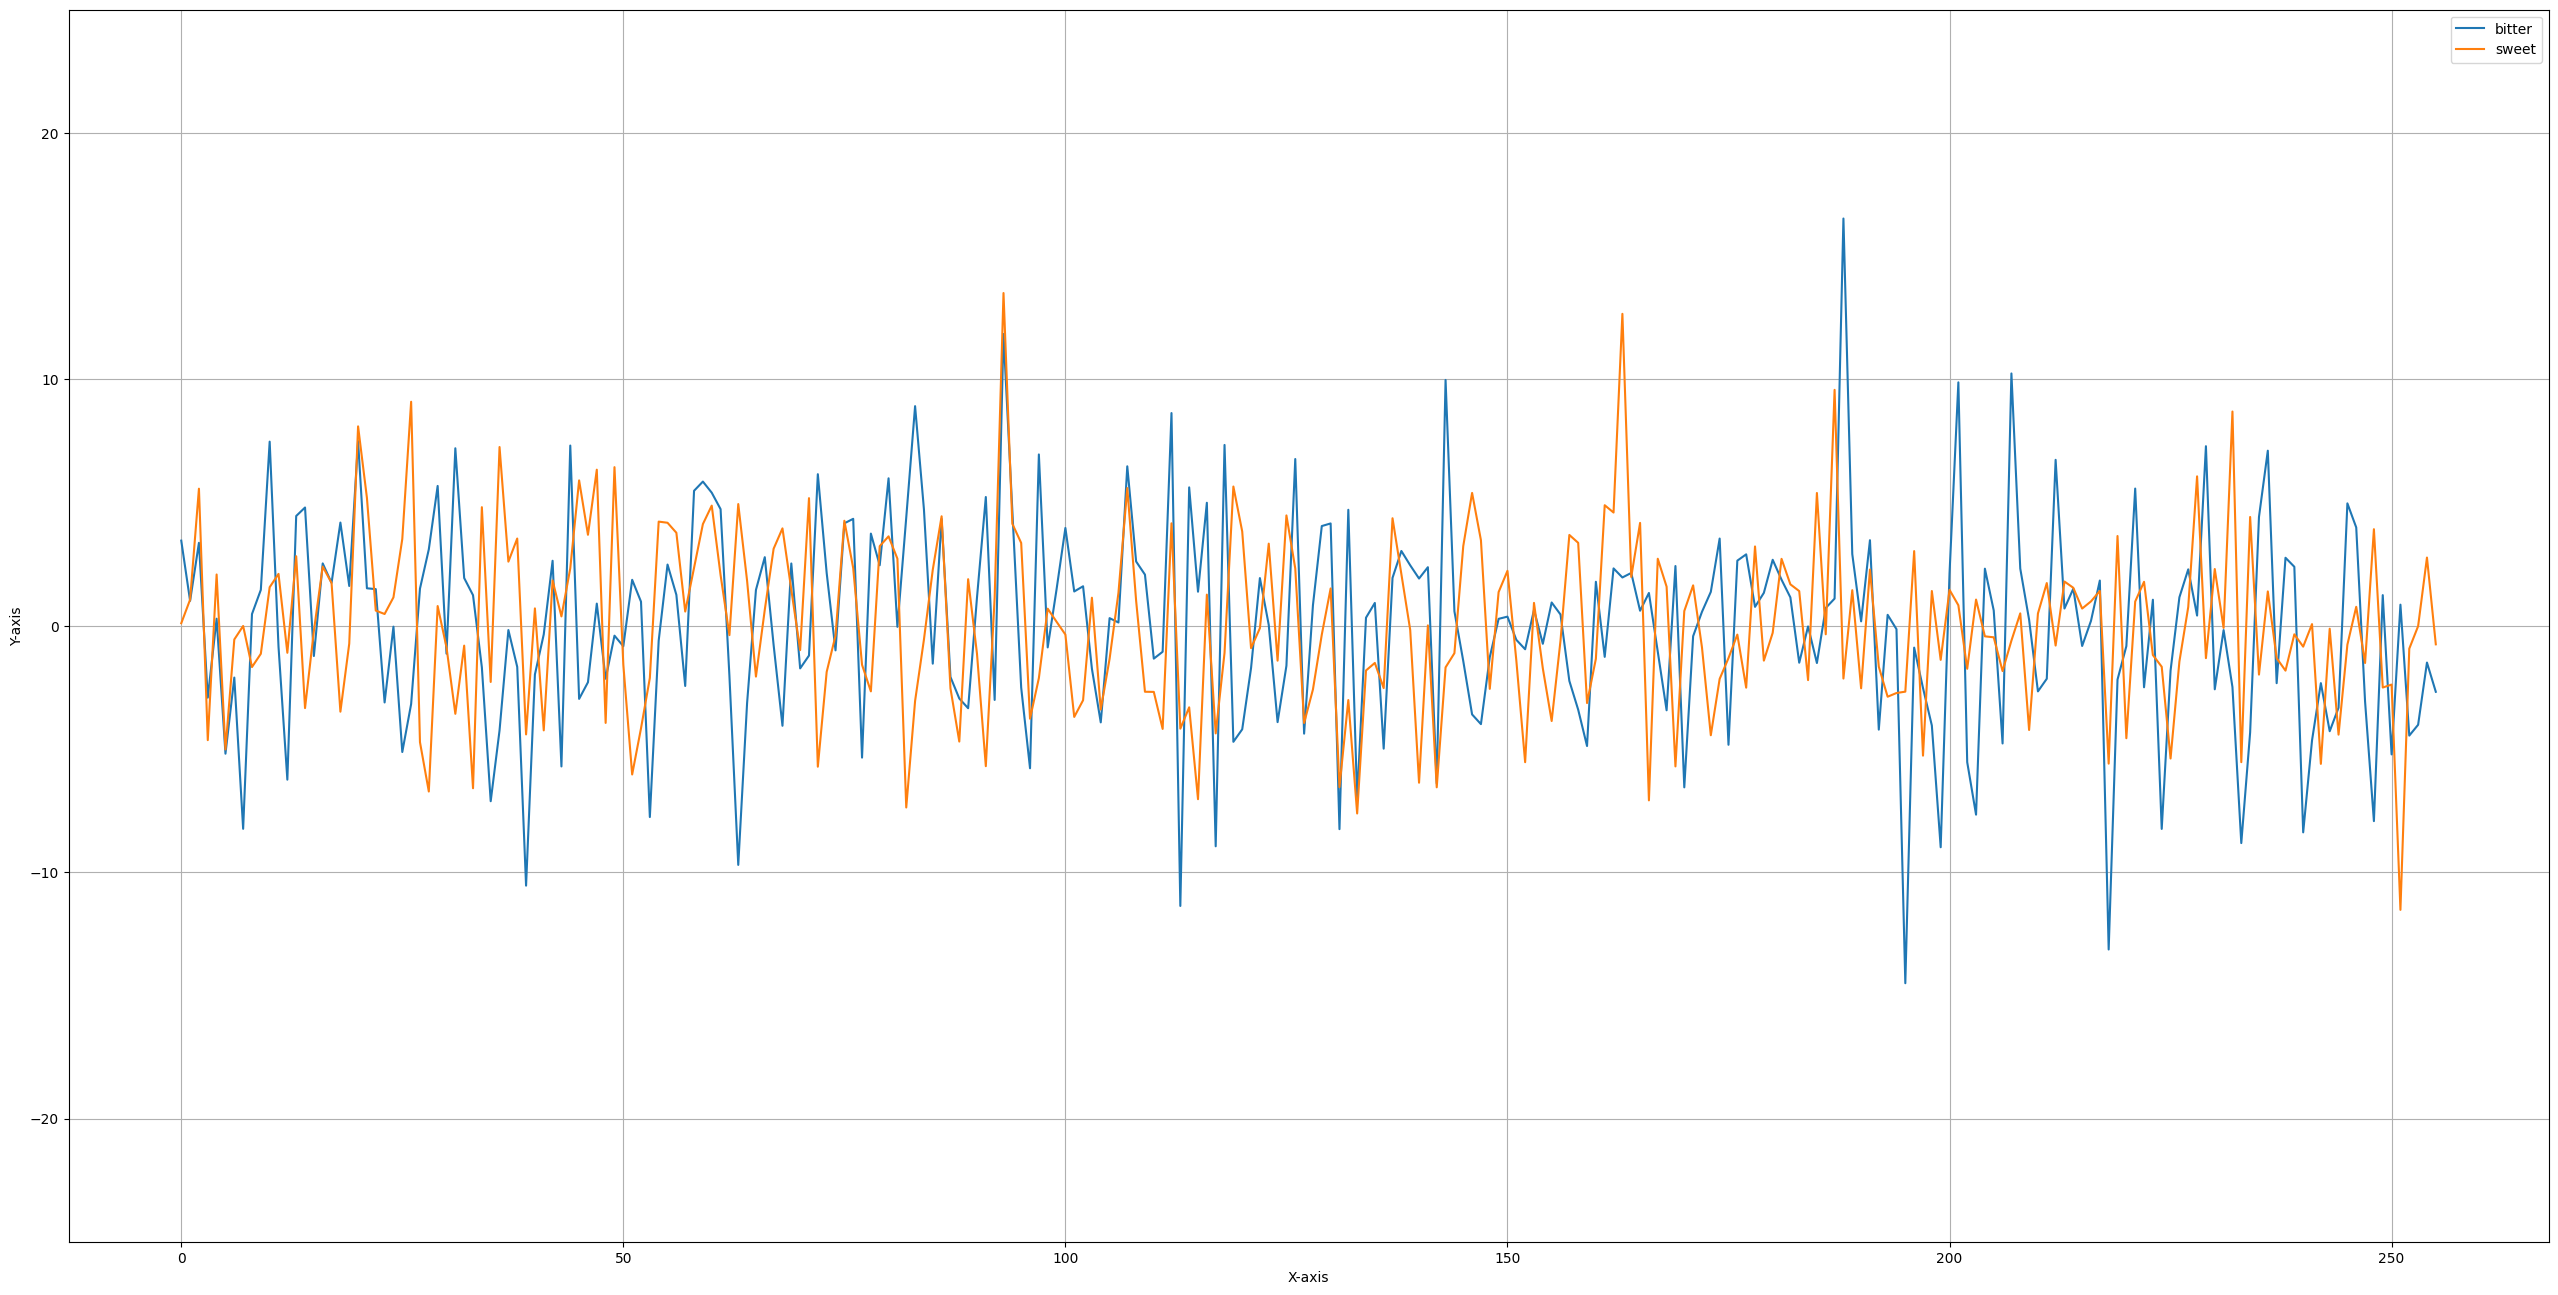

In [188]:
x = list(range(256))
plt.figure(figsize=(32, 16))

words = ["bitter", "sweet"]
for w in words:
    plt.plot(x, word_embeddings[word2idx[w]].tolist(), label=w)

plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()  # shows labels for each line
plt.ylim(-25, 25)
plt.grid(True)

# Save as image
plt.savefig("plot_5.png")

plt.show()